# Correlación de Spearman (parte 2)

Supongamos que somos Científicos de Datos en una empresa que desarrolla juegos en formato de aplicaciones móviles.

**Queremos saber si el "tiempo total de sesión" (el tiempo durante el cual un usuario juega el juego) está correlacionado con "compras en la app" (el dinero gastado por el usuario).**

## 1. Particularidades de este problema

- En últimas queremos saber si más tiempo total de sesión implica más compras en la app
- Pero:
    - Puede no haber relaciones lineales entre tiempo y compras. Por ejemplo, duplicar el tiempo de juego no implica duplicar el nivel de compra.
    - Puede haber "outliers" en los datos. Es decir jugadores que pasan mucho tiempo en la app y prácticamente no compran o jugadores con niveles muy altos de compra
    
Esto hace que probablemente la correlación de Pearson no resulte adecuada en este caso.

## 2. El problema del negocio y el problema de Ciencia de Datos

> **Problema de negocio:** ¿más tiempo de juego implica más compras "in-app"?

> **Problema de Ciencia de Datos:** ¿hay algún grado de correlación estadísticamente significativo entre las variables tiempo de juego y compras "in-app"?

## 3. Definir $H_0$ y $H_1$

- $H_0$: no hay correlación entre las variables tiempo de juego y compras "in-app" (índice de correlación estadísticamente igual a cero)
- $H_1$: las variables tiempo de juego y compras "in-app" están correlacionadas (índice de correlación estadísticamente diferente de cero)

## 4. Diseño del experimento

La lógica en este punto es similar a la de otras pruebas paramétricas y no paramétricas:

1. Definir $\alpha$. **Supondremos $\alpha = 0.05$**
2. Definir el tamaño del efecto. En este caso es el mismo $\rho$ e indica el mínimo nivel de correlación que queremos ser capaces de detectar. **Supondremos $\rho = 0.5$ (nivel medio de correlación)**
3. Definir la potencia de la prueba. En este caso es la probabilidad de correctamente detectar una correlación cuando esta realmente existe. **Supondremos una potencia de 0.9**
4. Calcular el tamaño de la muestra como si fuese correlación de Pearson ($n_{\text{pearson}}$)
5. Corregir el tamaño anterior para el caso de Spearman: $n_{\text{spearman}} = n_{\text{pearson}}/0.91$

Y en el paso 4 el $n_{\text{pearson}}$ se calcula usando como referencia el t-test para muestras independientes.

Así que veamos cómo estimar este tamaño de la muestra:

In [1]:
from statsmodels.stats.power import TTestIndPower
import math

# Parámetros definidos en el diseño
rho = 0.5           # Tamaño del efecto esperado
alpha = 0.05        # Nivel de significancia
power = 0.90        # Potencia de la prueba esperada

# Tamaño de la muestra para Pearson
analisis = TTestIndPower()
n_pearson = analisis.solve_power(
    effect_size=rho,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative='two-sided')

# Ajustar para Spearman
n_spearman = n_pearson / 0.91

print(f"Para detectar un rho de {rho} necesitamos:")
print(f"{math.ceil(n_pearson)} datos para Pearson")
print(f"{math.ceil(n_spearman)} datos para Spearman")

Para detectar un rho de 0.5 necesitamos:
86 datos para Pearson
94 datos para Spearman


## 5. Recolectar, explorar y preparar los datos

Supondremos que ya hemos recolectado los datos. Estos se encuentran en el dataset "dataset_correlacion_spearman.csv":

In [2]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/46-2026-04-EstadisticaInferencialNoParametrica/data/'

datos = pd.read_csv(RUTA + 'dataset_correlacion_spearman.csv')
datos

,tiempo_sesion,compras
0,11.5,49.2
1,9.6,20.1
2,11.9,48.2
3,14.6,131.0
4,9.3,21.1
...,...,...
178,9.2,23.1
179,18.2,421.5
180,12.0,5000.0
181,13.0,7000.0


En total tenemos 183 registros.

Veamos la relación entre las dos variables:

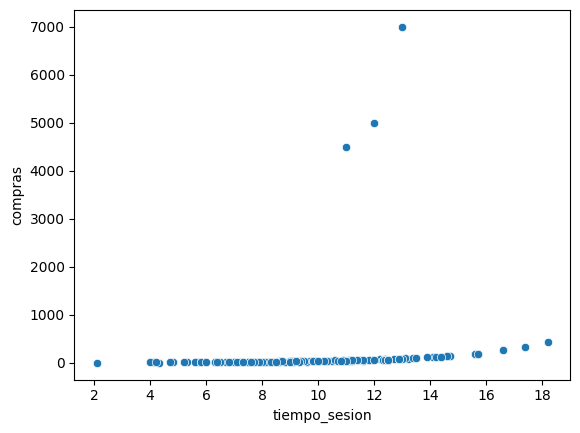

In [3]:
import seaborn as sns

sns.scatterplot(datos, x='tiempo_sesion', y='compras');

Observaciones:

- Existen varios "outliers"
- Y adicionalmente la relación entre las variables parece no ser lineal

Así que esto justifica el uso de la correlación de Spearman.

## 6. Calcular $\rho$ y aplicar la prueba estadística

En este caso podemos usar también "pingouin" para calcular tanto el índice de correlación como el resultado de la prueba estadística:

In [4]:
from pingouin import corr

resultados = corr(x=datos["tiempo_sesion"],
                 y = datos["compras"],
                 alternative = "two-sided", # "greater": rho>0, "less": rho<0
                 method="spearman", # "pearson" 
                 )
resultados

,n,r,CI95%,p-val,power
spearman,183,0.965778,"[0.95, 0.97]",5.094948e-108,1.0


Estos resultados nos muestran:

- El número de datos usado en la prueba (n=183)
- El valor de $\rho$ (= 0.96). En este caso nos indica un alto grado de relación monotónica positiva
- El intervalo de confianza del 95% (0.95 a 0.97)
- El valor p (5e-108)
- Y la potencia post-hoc: 1.0 (100%)

## 7. Interpretación de los resultados

El valor p que obtuvimos anteriormente (mucho menor que 0.05) nos confirma que estadísticamente el $\rho$ obtenido (0.96) es diferente de cero.

Y esto nos dice que:
- El "tiempo total de sesión" (el tiempo durante el cual un usuario juega el juego) está correlacionado con "compras en la app"
- En particular (debido a que $\rho$ es positivo) podemos decir que entre mayor sea el "tiempo total de sesión" mayores serán las "compras"
- Además, la potencia de la prueba (100%) nos indica que podemos estar totalmente seguros de que esa correlación encontrada es real